In [83]:
import matplotlib.pyplot as plt
import numpy as np
import openmm
from openmm import unit
from openmm import CustomExternalForce

%matplotlib inline

In [84]:
radius_negative = 105.0 * unit.nanometer
box_length = 1000.0 * unit.nanometer
temperature = 298.0 * unit.kelvin

In [105]:
def get_potentials(x_positions, radius, platform_name="Reference"):
    # Set up system.
    system = openmm.System()


    system.setDefaultPeriodicBoxVectors([box_length, 0.0, 0.0],
                                        [0.0, box_length, 0.0],
                                        [0.0, 0.0, box_length])
    
    
    slj_potential = CustomExternalForce(
            "step(box_length/2 - r_cut) * "
            "4 * epsilon * "
            "((sigma/radius)^12) "
            "- alpha * ((sigma / radius)^6);"
            "r_cut = radius * 2^(1/6)"
        )

    slj_potential.addGlobalParameter("box_length", box_length)
    slj_potential.addGlobalParameter("epsilon", 1.0)
    slj_potential.addGlobalParameter("sigma", radius_negative)
    slj_potential.addGlobalParameter("alpha", 0.0)
    slj_potential.addPerParticleParameter("radius") 

                        
    # Add a particle to the system 
    system.addParticle(mass=1.0)
    slj_potential.addParticle(0,[105.0 * unit.nanometer])
    

    # Add forces.
    
    system.addForce(slj_potential)
        
    for force in system.getForces():
        print(f"Energy function: {force.getEnergyFunction()}")
        #print(f"Nonbonded method: {force.getNonbondedMethod()}, Cutoff distance: {force.getCutoffDistance()}")
        #assert force.usesPeriodicBoundaryConditions()
        #assert not force.getUseLongRangeCorrection()
    
    # Set up platform and context. The platform_name is typically Reference or CUDA.
    platform = openmm.Platform.getPlatformByName(platform_name)
    dummy_integrator = openmm.LangevinIntegrator(
        temperature.value_in_unit(unit.kelvin), 0.0, 0.0)
    context = openmm.Context(system, dummy_integrator, platform)
    print(f"Using {context.getPlatform().getName()} platform.")
    if context.getPlatform().getName() == "CUDA":
        for cuda_property in ("Precision", "TempDirectory", "UseCpuPme", "DeviceIndex", "UseBlockingSync", "DeterministicForces"):
            print(f"{cuda_property}: {context.getPlatform().getPropertyValue(context, cuda_property)}")
    
    
    potential_energies = np.zeros(len(x_positions))
    for x_index, x_pos in enumerate(x_positions):
        context.setPositions([[x_pos, 0.0, 0.0]])
        state = context.getState(getEnergy=True)
        potential_energies[x_index] = (
            state.getPotentialEnergy()
            / (unit.BOLTZMANN_CONSTANT_kB * temperature * unit.AVOGADRO_CONSTANT_NA)
        )
    
    return potential_energies

In [110]:
x_positions = [i/100*box_length  for i in range(-49, 49)]

potential_vals = get_potentials(x_positions, radius_negative)

Energy function: step(box_length/2 - r_cut) * 4 * epsilon * ((sigma/radius)^12) - alpha * ((sigma / radius)^6);r_cut = radius * 2^(1/6)
Using Reference platform.


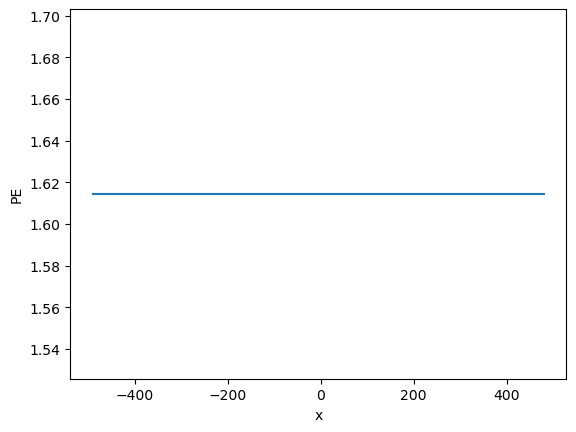

In [111]:
x_positions_list = [i/100*1000  for i in range(-49, 49)]

plt.plot(x_positions_list, potential_vals)
plt.xlabel("x")
plt.ylabel("PE")
plt.show()